In [94]:
#RUN INITIALLY
!pip install ucimlrepo

In [95]:
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier



In [96]:
seed = 1234
np.random.seed(seed)  

# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets.values.ravel()

# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [97]:
from sklearn.model_selection import train_test_split

# first split: train+val vs test (80/20)
X_temp, X_te, y_temp, y_te = train_test_split(
    X, y, test_size=0.2, random_state=seed, shuffle=True
)

# second split: train vs validation (75/25 of 80%)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=seed, shuffle=True
)

print("Train size:", len(X_tr))
print("Validation size:", len(X_val))
print("Test size:", len(X_te))

Train size: 3897
Validation size: 1300
Test size: 1300


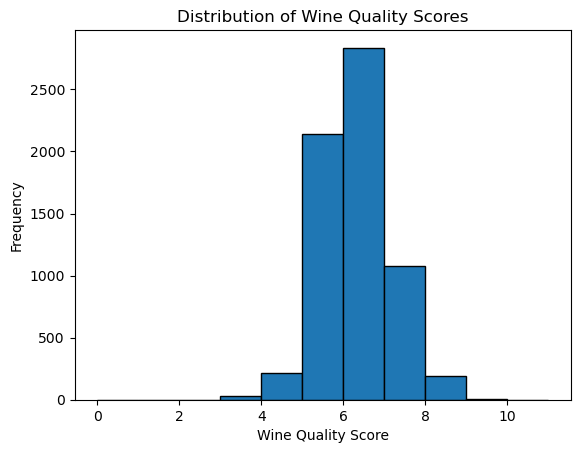

In [98]:
plt.hist(y, bins=range(0, 12), edgecolor='black')
plt.xlabel("Wine Quality Score")
plt.ylabel("Frequency")
plt.title("Distribution of Wine Quality Scores")
plt.show()

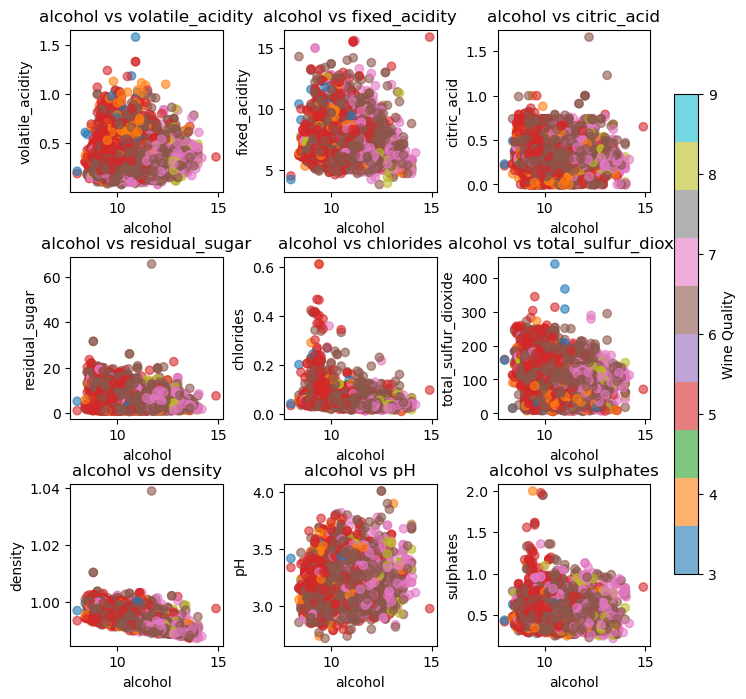

In [99]:
# Make a figure with 9 subplots
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

diff_y = ['volatile_acidity', 'fixed_acidity', 'citric_acid','residual_sugar', 
          'chlorides', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates']

# plot each subplot
for ax, y_name in zip(axes.flat, diff_y):
    sc = ax.scatter(X['alcohol'], X[y_name], c=y, cmap='tab10', alpha=0.6)
    ax.set_xlabel('alcohol')
    ax.set_ylabel(y_name)
    ax.set_title(f'alcohol vs {y_name}')

# adjust spacing and leave room for colorbar legend
fig.subplots_adjust(right=0.85, wspace=0.4, hspace=0.4)

# add colorbar on the right
cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])
fig.colorbar(sc, cax=cbar_ax, label="Wine Quality")

plt.show()

In [100]:
plot_kwargs = {'cmap': 'viridis',
               'response_method': 'predict',
               'plot_method': 'pcolormesh',
               'shading': 'auto',
               'alpha': 0.5,
               'grid_resolution': 100}

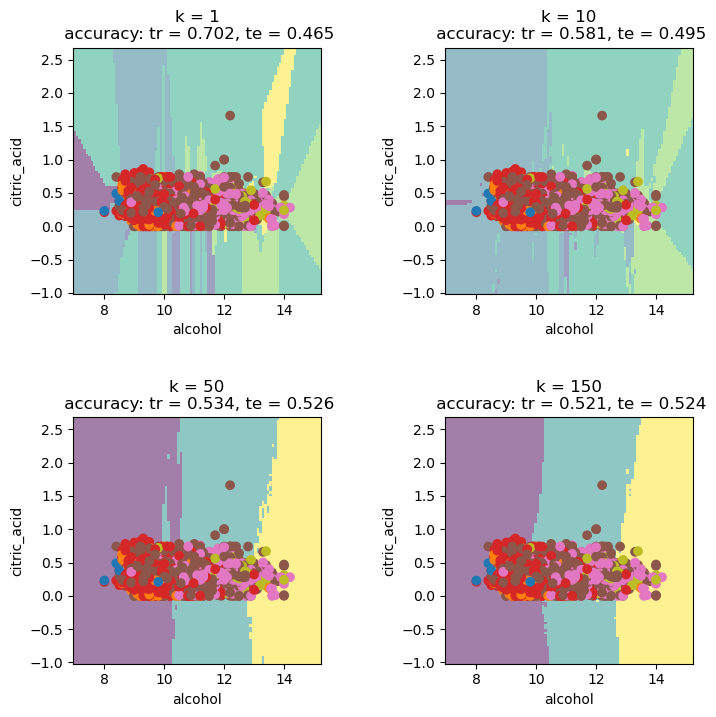

In [101]:
figure, axes = plt.subplots(2, 2, figsize=(8, 8))

plt.subplots_adjust(hspace=0.5, wspace=0.5)
label_enc = LabelEncoder()
y_vs = label_enc.fit_transform(y_tr)

#looking at alc and chlorides only
X_tr_2 = X_tr[['alcohol','citric_acid']]
X_te_2 = X_te[['alcohol','citric_acid']]

i = 0
for k in [1, 10, 50, 150]:
    knn_class = KNeighborsClassifier(n_neighbors=k)
    knn_class.fit(X_tr_2, y_tr)
    y_pred_tr = knn_class.predict(X_tr_2)
    y_pred_te = knn_class.predict(X_te_2)
    disp = DecisionBoundaryDisplay.from_estimator(knn_class, X_tr_2, 
                                                  ax = axes[i//2, i%2], **plot_kwargs)
    axes[i//2, i%2].scatter(X_tr_2['alcohol'], X_tr_2["citric_acid"],
                            c=y_vs, cmap='tab10')
    axes[i//2, i%2].set_title(
        f'k = {k}\n accuracy: tr = {accuracy_score(y_tr, y_pred_tr):.3f}, te = {accuracy_score(y_te, y_pred_te):.3f}')
    i += 1
    
plt.show()

Overfitting at smaller k values, begins to overfit at k=150. 
Since accuracies are at around 50%, we can tell this isn't a good classifier for the data.

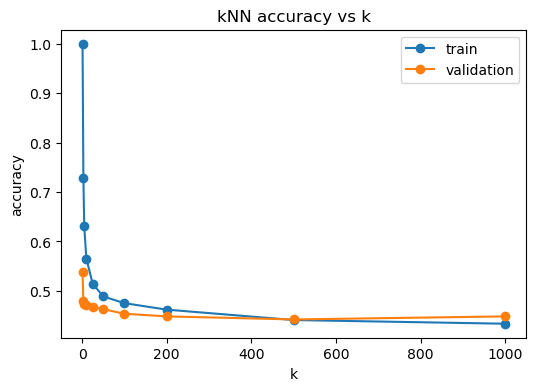

In [102]:


k_vals = [1, 3, 5, 10, 25, 50, 100, 200, 500, 1000]

train_acc = []
val_acc = []

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)

    train_acc.append(knn.score(X_tr, y_tr))
    val_acc.append(knn.score(X_val, y_val))

# plot
plt.figure(figsize=(6,4))
plt.plot(k_vals, train_acc, marker='o', label='train')
plt.plot(k_vals, val_acc, marker='o', label='validation')

plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('kNN accuracy vs k')
plt.legend()
plt.show()

Can see underfitting at the start and overfitting at the end. Same conclusion as prev cell, where thr 50% acc tells us knn isnt the ideal choice for the classification of this dataset.

In [103]:
# feature scaling
scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te = scaler.transform(X_te)

Best k: 1


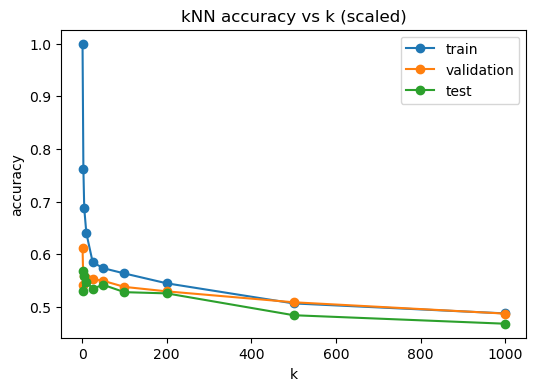

Final kNN test accuracy: 0.5684615384615385


In [104]:
k_vals = [1, 3, 5, 10, 25, 50, 100, 200, 500, 1000]

train_acc = []
val_acc = []

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)

    train_acc.append(knn.score(X_tr, y_tr))
    val_acc.append(knn.score(X_val, y_val))

best_k = k_vals[val_acc.index(max(val_acc))]
print("Best k:", best_k)

test_acc = []

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)
    test_acc.append(knn.score(X_te, y_te))


plt.figure(figsize=(6,4))
plt.plot(k_vals, train_acc, marker='o', label='train')
plt.plot(k_vals, val_acc, marker='o', label='validation')
plt.plot(k_vals, test_acc, marker='o', label='test')

plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('kNN accuracy vs k (scaled)')
plt.legend()
plt.show()


knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_tr, y_tr)

knn_test_accuracy = knn_best.score(X_te, y_te)

print("Final kNN test accuracy:", knn_test_accuracy)

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial lo

Best C: 0.1
Final Logistic Regression test accuracy: 0.5376923076923077


/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


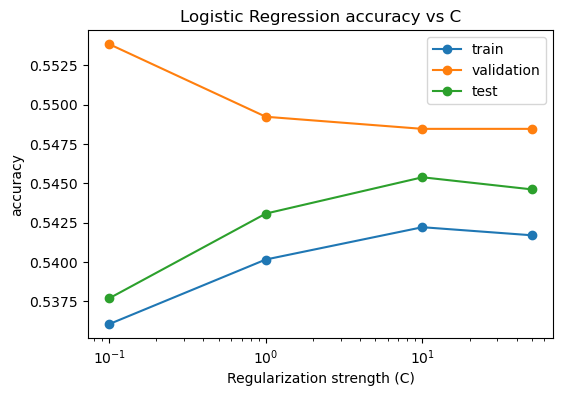

In [105]:
train_accuracies = []
val_accuracies = []
test_accuracies = []

cs = [0.1, 1, 10, 50]

# sweep over C
for c in cs:
    classifier = LogisticRegression(
        penalty='l1',
        C=c,
        solver='liblinear',
        fit_intercept=True,
        random_state=seed
    )
    
    classifier.fit(X_tr, y_tr)

    train_accuracies.append(classifier.score(X_tr, y_tr))
    val_accuracies.append(classifier.score(X_val, y_val))
    test_accuracies.append(classifier.score(X_te, y_te))  # for visualization only

# pick best C using validation
best_c = cs[val_accuracies.index(max(val_accuracies))]
print("Best C:", best_c)

# final model (trained on training set only)
best_model = LogisticRegression(
    penalty='l1',
    C=best_c,
    solver='liblinear',
    fit_intercept=True,
    random_state=seed
)

best_model.fit(X_tr, y_tr)

# final test accuracy (ONLY ONCE)
final_test_acc = best_model.score(X_te, y_te)
print("Final Logistic Regression test accuracy:", final_test_acc)

# plot
plt.figure(figsize=(6,4))
plt.semilogx(cs, train_accuracies, marker='o', label='train')
plt.semilogx(cs, val_accuracies, marker='o', label='validation')
plt.semilogx(cs, test_accuracies, marker='o', label='test')

plt.xlabel('Regularization strength (C)')
plt.ylabel('accuracy')
plt.title('Logistic Regression accuracy vs C')
plt.legend()
plt.show()

Underfitting, as both accuracies are low. Regularization has little impact. 
Linear decision boundary not the move for this data set. 

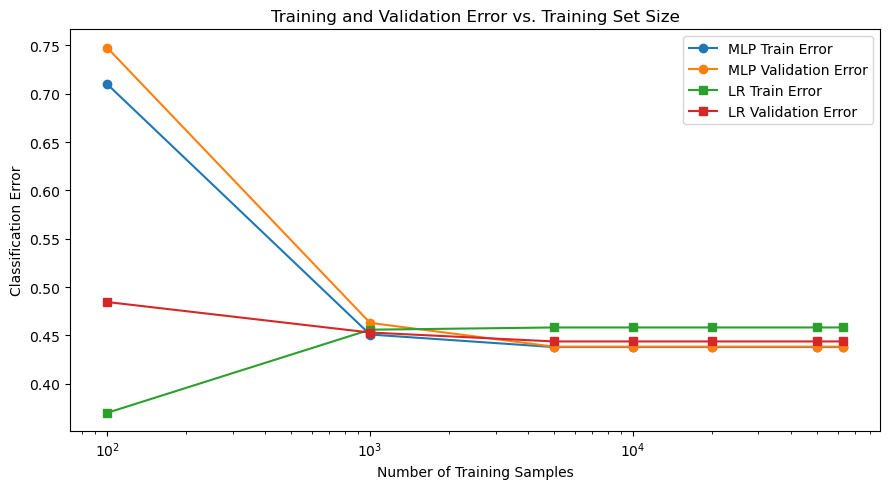

In [106]:
# learning curves w/ neural network
n_tr_values = [100, 1000, 5000, 10000, 20000, 50000, 63000]

mlp_train_errors = []
mlp_val_errors = []
lr_train_errors = []
lr_val_errors = []

for i in n_tr_values:
    X_train_sub = X_tr[:i]
    y_train_sub = y_tr[:i]

    # MLP
    mlp = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        max_iter=1000,
        early_stopping=True,
        random_state=seed
    )
    mlp.fit(X_train_sub, y_train_sub)

    mlp_train_errors.append(1 - mlp.score(X_train_sub, y_train_sub))
    mlp_val_errors.append(1 - mlp.score(X_val, y_val))

    # Logistic Regression
    lr = LogisticRegression(random_state=seed)
    lr.fit(X_train_sub, y_train_sub)

    lr_train_errors.append(1 - lr.score(X_train_sub, y_train_sub))
    lr_val_errors.append(1 - lr.score(X_val, y_val))

# plot
plt.figure(figsize=(9, 5))
plt.plot(n_tr_values, mlp_train_errors, marker='o', label='MLP Train Error')
plt.plot(n_tr_values, mlp_val_errors, marker='o', label='MLP Validation Error')
plt.plot(n_tr_values, lr_train_errors, marker='s', label='LR Train Error')
plt.plot(n_tr_values, lr_val_errors, marker='s', label='LR Validation Error')

plt.xscale('log')
plt.xlabel('Number of Training Samples')
plt.ylabel('Classification Error')
plt.title('Training and Validation Error vs. Training Set Size')
plt.legend()
plt.tight_layout()
plt.show()

Best hidden size: 50
Final Neural Network test accuracy: 0.54


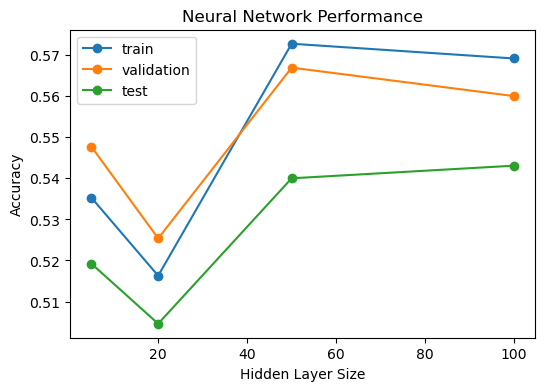

In [107]:
hidden_sizes = [5, 20, 50, 100]

train_accs = []
val_accs = []
test_accs = []

for h in hidden_sizes:
    nn = MLPClassifier(
        hidden_layer_sizes=(h,),
        activation='relu',
        solver='adam',
        max_iter=1000,
        early_stopping=True,
        random_state=seed
    )

    nn.fit(X_tr, y_tr)

    train_accs.append(nn.score(X_tr, y_tr))
    val_accs.append(nn.score(X_val, y_val))
    test_accs.append(nn.score(X_te, y_te))  # for plotting only

# pick best hidden size using validation
best_h = hidden_sizes[val_accs.index(max(val_accs))]
print("Best hidden size:", best_h)

# final model
best_nn = MLPClassifier(
    hidden_layer_sizes=(best_h,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=seed
)

best_nn.fit(X_tr, y_tr)

# final test accuracy
nn_test_accuracy = best_nn.score(X_te, y_te)
print("Final Neural Network test accuracy:", nn_test_accuracy)

# plot
plt.figure(figsize=(6,4))
plt.plot(hidden_sizes, train_accs, marker='o', label='train')
plt.plot(hidden_sizes, val_accs, marker='o', label='validation')
plt.plot(hidden_sizes, test_accs, marker='o', label='test')

plt.xlabel("Hidden Layer Size")
plt.ylabel("Accuracy")
plt.title("Neural Network Performance")
plt.legend()
plt.show()

Final Random Forest Accuracy: 0.6431


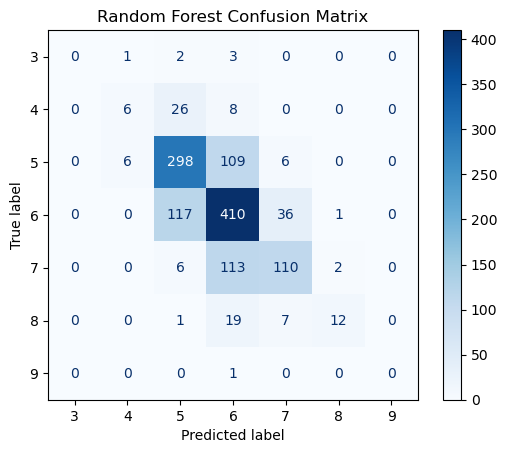

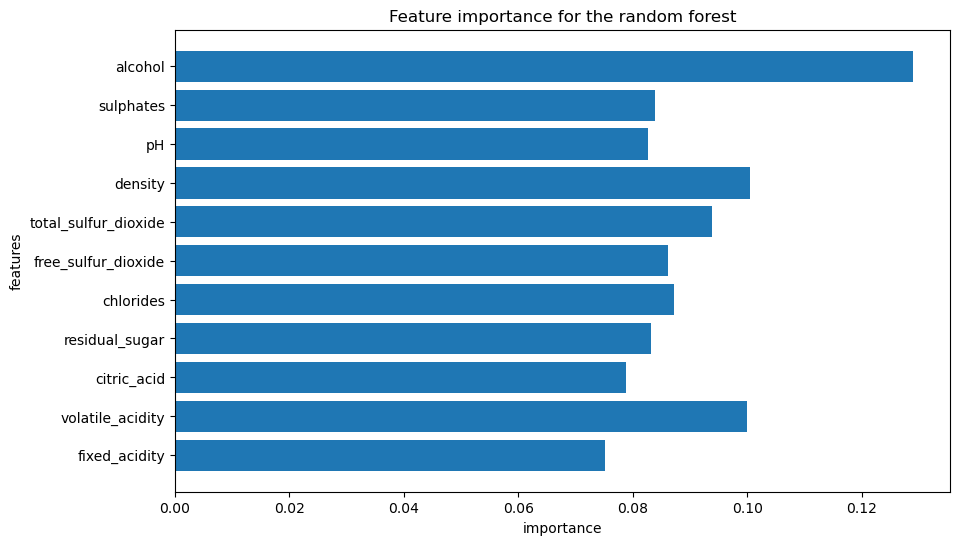

In [108]:
# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=seed)
rf.fit(X_tr, y_tr)

# final test accuracy
rf_test_accuracy = rf.score(X_te, y_te)
print(f"Final Random Forest Accuracy: {rf_test_accuracy:.4f}")

# confusion matrix
ConfusionMatrixDisplay.from_estimator(rf, X_te, y_te, cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

# feature importance
important = rf.feature_importances_
features = wine_quality.data.features.columns

plt.figure(figsize=(10, 6))
plt.barh(features, important)
plt.xlabel("importance")
plt.ylabel("features")
plt.title("Feature importance for the random forest")
plt.show()

kNN: 0.5684615384615385
Logistic: 0.5376923076923077
Neural Net: 0.54
Random Forest: 0.6430769230769231


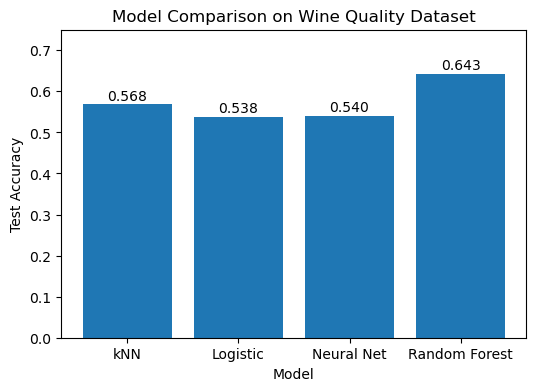

In [ ]:
import matplotlib.pyplot as plt

# use FINAL test accuracies from each model
knn_best = knn_test_accuracy
logistic_best = final_test_acc
mlp_best = nn_test_accuracy
rf_best = rf_test_accuracy

# print to verify
print("kNN:", knn_best)
print("Logistic:", logistic_best)
print("Neural Net:", mlp_best)
print("Random Forest:", rf_best)

# bar chart
models = ['kNN', 'Logistic', 'Neural Net', 'Random Forest']
test_acc_values = [knn_best, logistic_best, mlp_best, rf_best]

plt.figure(figsize=(6,4))
plt.bar(models, test_acc_values)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Model Comparison on Wine Quality Dataset")

# labels
for i, v in enumerate(test_acc_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.ylim(0, 0.75)
plt.show()